# Phase 2: Data Preprocessing

## Objectives

- Handle missing values
- Remove duplicates
- Handle outliers
- Encode categorical variables
- Scale numerical features
- Handle skewed distributions
- Perform feature engineering
- Feature selection

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.stats import skew

import warnings
warnings.filterwarnings("ignore")

In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
#Load Dataset
df = pd.read_csv("/home/aximsoft/Documents/AximSoft_EOWA/Week_08/Notebooks/dataset/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Dataset Shape
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 1460
Columns : 81


In [5]:
# Missing Values
missing = df.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [6]:
# Missing Value Percentage
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent = missing_percent[missing_percent>0].sort_values(ascending=False)
missing_percent

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [7]:
# Drop Columns Having More Than 50% Missing Values
missing_cols = missing_percent[missing_percent>50].index
df.drop(columns=missing_cols,inplace=True)

print(df.shape)

(1460, 76)


In [8]:
# Numerical and Categorical Columns
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

print("Numerical :",len(num_cols))
print("Categorical :",len(cat_cols))

Numerical : 38
Categorical : 38


In [9]:
# Missing  numeric Values
missing = df.select_dtypes(include=np.number).isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
missing

LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64

In [10]:
# Missing  categorical  Values
missing = df.select_dtypes(include="object").isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
missing

FireplaceQu     690
GarageQual       81
GarageFinish     81
GarageCond       81
GarageType       81
BsmtExposure     38
BsmtFinType2     38
BsmtCond         37
BsmtQual         37
BsmtFinType1     37
Electrical        1
dtype: int64

In [11]:
# Fill Remaining Missing Values

num_cols = df.select_dtypes(include=["number"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [12]:
df=df.drop('Id',axis=1)

In [13]:
df.shape

(1460, 75)

In [14]:
print(df.isnull().sum().sum())

0


In [15]:
# Duplicate Rows
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [16]:
# Remove Duplicate Rows
df.drop_duplicates(inplace=True)

print(df.shape)

(1460, 75)


In [17]:
# Numerical Features
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

In [18]:
# Skewness of Numerical Features
skewness = df[num_cols].skew().sort_values(ascending=False)
skewness

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.677616
LotFrontage       2.409147
OpenPorchSF       2.364342
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
YrSold            0.096269
FullBath          0.036562
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearBuilt        -0.613461
GarageYrBlt      -0.678333
d

In [19]:
# Highly Skewed Features
high_skew = skewness[abs(skewness) > 0.75]
high_skew

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.677616
LotFrontage       2.409147
OpenPorchSF       2.364342
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
dtype: float64

In [20]:
# Log Transformation
for col in high_skew.index:
    if col != "SalePrice":
        df[col] = np.log1p(df[col])

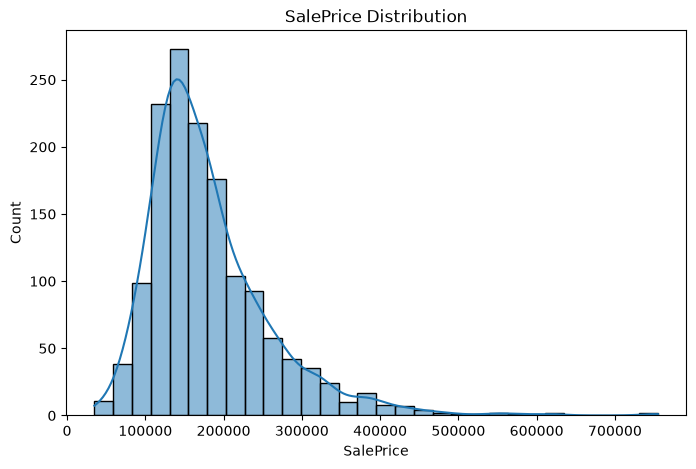

In [21]:
# SalePrice Distribution Before Transformation
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"],kde=True,bins=30)
plt.title("SalePrice Distribution")
plt.show()

In [22]:
# Skewness After Transformation
df[num_cols].skew().sort_values(ascending=False)

PoolArea         14.363102
3SsnPorch         7.734975
LowQualFinSF      7.460317
MiscVal           5.170704
BsmtHalfBath      3.933064
KitchenAbvGr      3.869414
ScreenPorch       3.150409
BsmtFinSF2        2.523694
EnclosedPorch     2.112275
SalePrice         1.882876
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
MasVnrArea        0.503532
2ndFlrSF          0.289643
MSSubClass        0.248997
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
WoodDeckSF        0.153537
YrSold            0.096269
1stFlrSF          0.080114
FullBath          0.036562
GrLivArea        -0.006140
OpenPorchSF      -0.023397
LotArea          -0.137404
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearBuilt        -0.613461
BsmtFinSF1       -0.618410
GarageYrBlt      -0.678333
LotFrontage      -0.870006
BsmtUnfSF        -2.186504
TotalBsmtSF      -5.154670
d

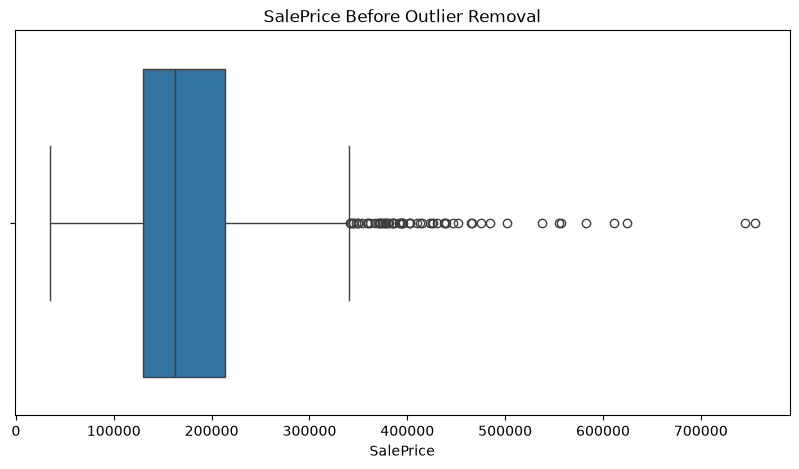

In [23]:
# Boxplot Before Outlier T
plt.figure(figsize=(10,5))
sns.boxplot(x=df["SalePrice"])
plt.title("SalePrice Before Outlier Removal")
plt.show()

In [24]:
# IQR Calculation
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)
IQR = Q3 - Q1

In [25]:
# Remove Outliers
df = df[
    (df["SalePrice"] >= Q1 - 1.5*IQR) &
    (df["SalePrice"] <= Q3 + 1.5*IQR)
]

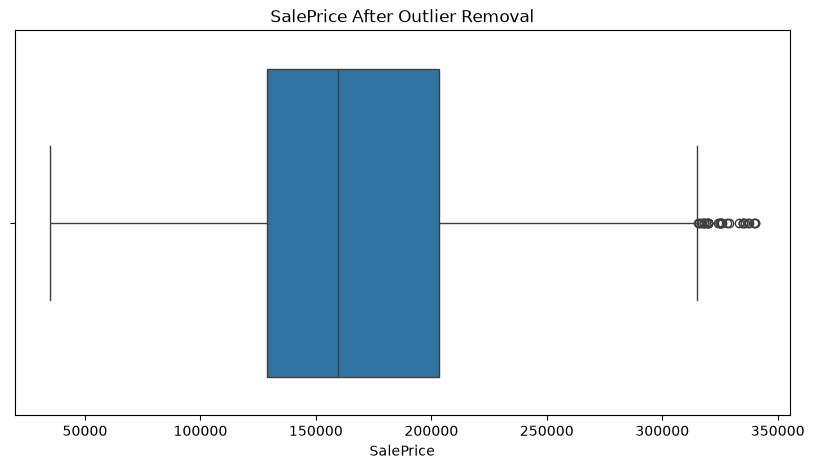

In [26]:
# Boxplot After Outlier Removal
plt.figure(figsize=(10,5))
sns.boxplot(x=df["SalePrice"])
plt.title("SalePrice After Outlier Removal")
plt.show()

In [27]:
#Encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    

In [28]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [29]:
df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,4.110874,4.189655,9.042040,7,5,2003,2003,5.283204,6.561031,0.0,...,0,0,0,0,1,0,0,0,1,0
1,3.044522,4.394449,9.169623,6,8,1976,1976,0.000000,6.886532,0.0,...,0,0,0,0,1,0,0,0,1,0
2,4.110874,4.234107,9.328212,7,5,2001,2002,5.093750,6.188264,0.0,...,0,0,0,0,1,0,0,0,1,0
3,4.262680,4.110874,9.164401,7,5,1915,1970,0.000000,5.379897,0.0,...,0,0,0,0,1,0,0,0,0,0
4,4.110874,4.442651,9.565284,8,5,2000,2000,5.860786,6.486161,0.0,...,0,0,0,0,1,0,0,0,1,0


In [30]:
# 1 Feature Engineering - House Age
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

In [31]:
# 2 Feature Engineering - Total Bathrooms2
df["TotalBathrooms"] = (
    df["FullBath"] +
    0.5*df["HalfBath"] +
    df["BsmtFullBath"] +
    0.5*df["BsmtHalfBath"]
)

In [32]:
# 3 Feature Engineering - Total Square Feet3
df["TotalSF"] = (
    df["TotalBsmtSF"] +
    df["1stFlrSF"] +
    df["2ndFlrSF"]
)

In [33]:
# 4 Feature Engineering - Total Porch Area
df["TotalPorchArea"] = (
    df["OpenPorchSF"] +
    df["EnclosedPorch"] +
    df["3SsnPorch"] +
    df["ScreenPorch"]
)

In [34]:
# 5 Feature Engineering - Remodeled House
df["RemodeledHouse"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)

In [35]:
df.shape

(1399, 239)

In [36]:
# Check Newly Created Features
df[["HouseAge","TotalBathrooms","TotalSF","TotalPorchArea","RemodeledHouse"]].head()

,HouseAge,TotalBathrooms,TotalSF,TotalPorchArea,RemodeledHouse
0,5,3.500000,20.257977,4.127134,0
1,31,2.346574,14.282490,0.000000,0
2,7,3.500000,20.415959,3.761200,1
3,91,2.000000,20.127741,9.192991,1
4,8,3.500000,21.048414,4.442651,0


In [37]:
# Correlation with SalePrice
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
corr

SalePrice           1.000000
OverallQual         0.784294
GrLivArea           0.687767
TotalBathrooms      0.633456
GarageCars          0.628013
                      ...   
BsmtQual_TA        -0.532185
KitchenQual_TA     -0.547400
GarageFinish_Unf   -0.558233
HouseAge           -0.564865
ExterQual_TA       -0.611414
Name: SalePrice, Length: 239, dtype: float64

In [38]:
# Top 20 Important Features
top=corr.head(20)
top

SalePrice           1.000000
OverallQual         0.784294
GrLivArea           0.687767
TotalBathrooms      0.633456
GarageCars          0.628013
GarageArea          0.607230
ExterQual_Gd        0.588472
FullBath            0.577369
YearBuilt           0.564558
YearRemodAdd        0.541161
1stFlrSF            0.538539
Foundation_PConc    0.521064
KitchenQual_Gd      0.486470
GarageYrBlt         0.475781
TotRmsAbvGrd        0.472292
OpenPorchSF         0.460083
Fireplaces          0.453010
BsmtFinType1_GLQ    0.420041
BsmtQual_Gd         0.413615
MasVnrArea          0.374104
Name: SalePrice, dtype: float64

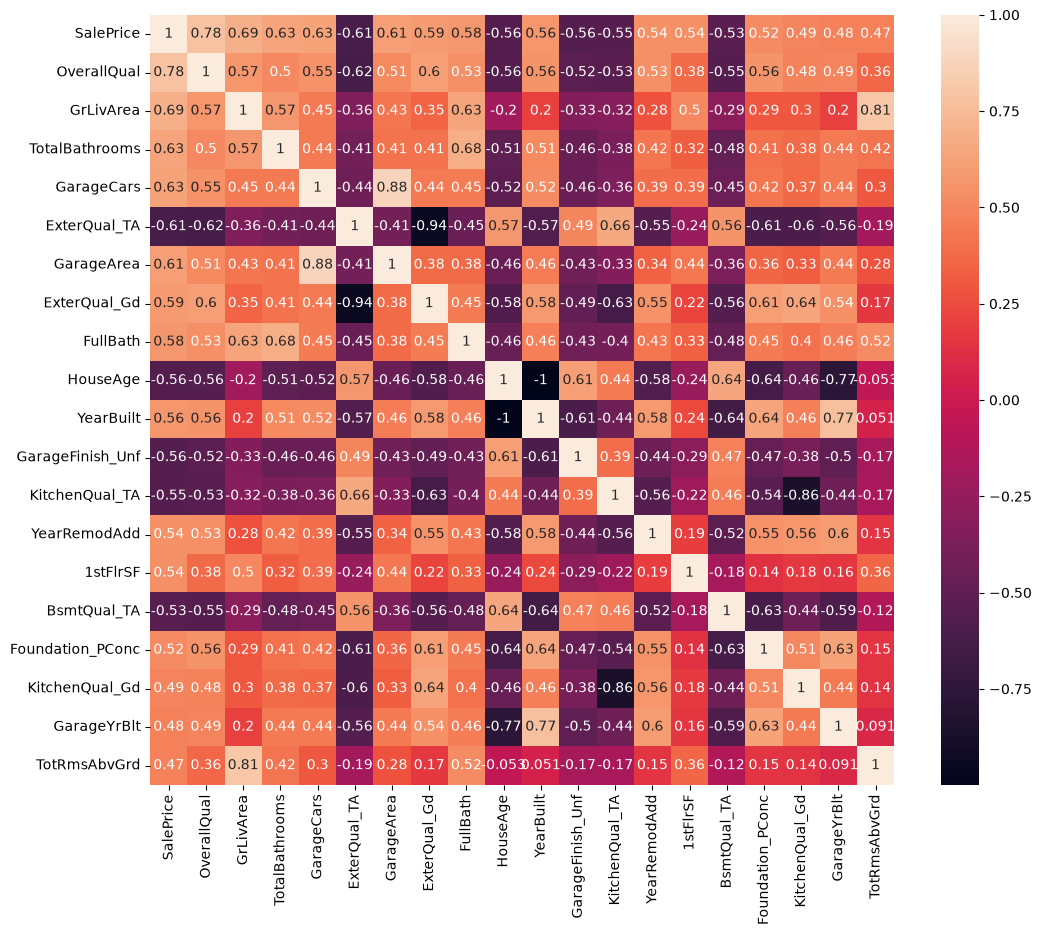

In [39]:
top_features = corr.abs().sort_values(ascending=False).head(20).index
 
plt.figure(figsize=(12, 10))

sns.heatmap(df[top_features].corr(), annot=True)

plt.show()
 

In [40]:
# Save Cleaned Dataset
df.to_csv("/home/aximsoft/Documents/AximSoft_EOWA/Week_08/Notebooks/dataset/house_prices_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [41]:
cat_cols = df.select_dtypes(include=["object"]).columns
cat_cols

Index([], dtype='str')